In [2]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm

# Tasks to answer 
In 2(i), select the trend that works the best. And in the subsequent assignments that use data without trend, work specifically with the one you selected.
In 2(ii), be prepared to explain the idea of the stationarity test you applied.
In (2iii), use a visual method (of your choice) to justify whether considering seasonality is appropriate. Additionally, perform a formal statistical test for seasonality and be ready to explain your choice of methodology.
Remember that interpreting the trend coefficient is not always straightforward. Aim for a precise interpretation, especially if you have opted for a non-linear trend.
In 3(iii), to receive the highest grade, you must be able to explain what ACF and PACF are and justify your choice of ARIMA parameters (p, d, q).
In (3v), Use the Durbin-Watson test to check residuals for autocorrelation. You should be able to explain its mechanism and interpret the results. Note: The Ljung-Box test was not covered in lectures; if you choose to use it, please study it independently and be ready to explain its core idea.
In task 4 (Forecasting), You are expected to work through forecasts and confidence intervals independently. Follow the basic ARIMA forecasting principles from the lecture slides. Crucial: If you used classical detrending and deseasonalization, remember to "re-seasonalize" and add the trend back to your final forecast.
Open-ended Question (5): This task is exploratory. Analyze your specific dataset and determine which methods, in your opinion, yield the best results. We look forward to hearing your research findings during the oral discussion.

In [3]:
df = pd.read_csv('data/data.csv', parse_dates=['observation_date'])

### Task 1

1. (0.25) Load the time series and plot a graph. Describe the main characteristics of the series: overall trend; presence of a trend; presence of seasonality; possible structural changes or anomalies.

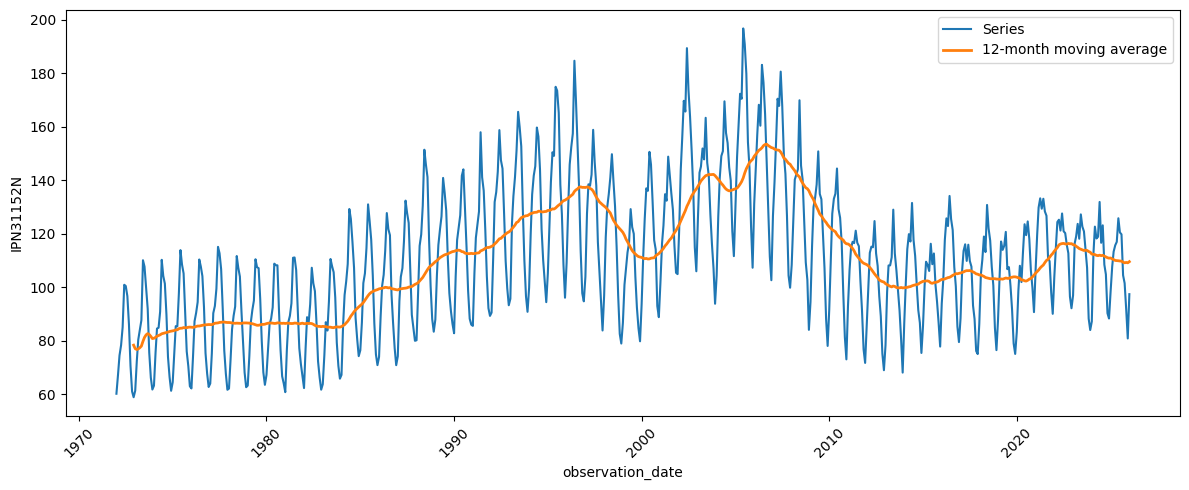

In [4]:
plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=df, x='observation_date', y='IPN31152N', label='Series')
ma12 = df['IPN31152N'].rolling(window=24, min_periods=12).mean()
ax.plot(df['observation_date'], ma12, label='12-month moving average', color='C1', linewidth=2)
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()


### Task 2

(i) (0.25) Evaluate the model trend: linear; quadratic; exponential. For each model: plot the corresponding trend; overlay it on the original series.

(ii) (0.25) Perform detrending for each model and plot the resulting residuals; compare their behavior. Check the stationarity of the detrended series.

(iii) (0.25) Investigate seasonality: plot the corresponding graphs; formally test for its presence;

(iv) (0.25) Build a regression model with the trend and seasonal dummy variables. Interpret the trend coefficients and the seasonality coefficients. Save the residuals from this model they will be used in Task 3.

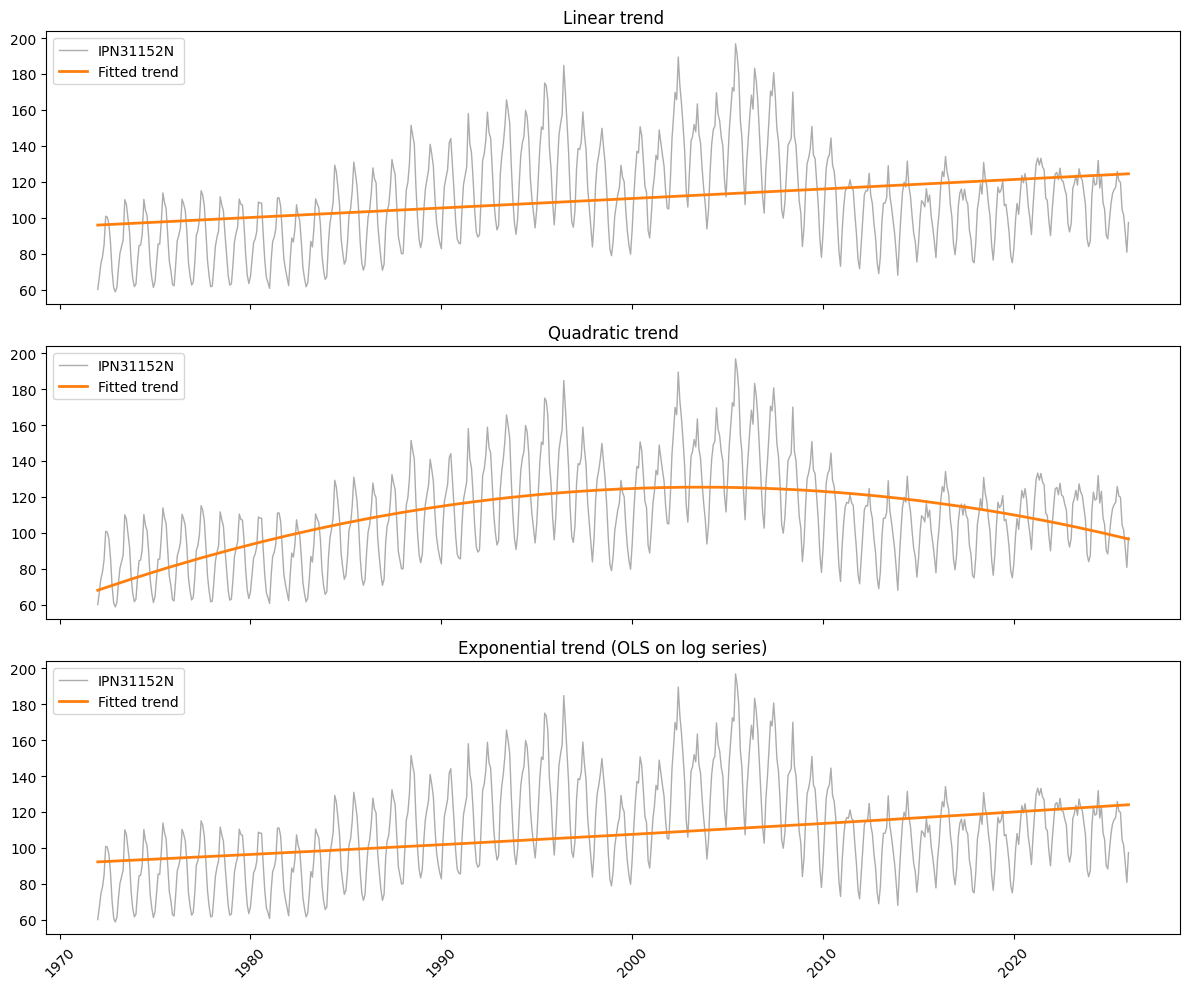

Linear:    R = 0.0947
Quadratic: R = 0.3130
Log-linear (for exp trend): R = 0.1204


In [5]:
# task i. Evaluate model trends: linear;quadratic;exponential. For each model: plot the corresponding trend; overlay it on the original series.
import numpy as np

y = df['IPN31152N'].to_numpy()
t = np.arange(len(df), dtype=float)
timing = df['observation_date']

# Linear - do you remember the formula?
X_lin = sm.add_constant(t)
fit_lin = sm.OLS(y, X_lin).fit()
trend_lin = fit_lin.fittedvalues
# Quadratic - do you remember the formula?
X_quad = sm.add_constant(np.column_stack([t, t**2]))
fit_quad = sm.OLS(y, X_quad).fit()
trend_quad = fit_quad.fittedvalues
# Exponential (log-linear) - do you remember the formula?
log_y = np.log(y)
X_exp = sm.add_constant(t)
fit_exp = sm.OLS(log_y, X_exp).fit()
trend_exp = np.exp(fit_exp.fittedvalues)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
titles = [
    'Linear trend',
    'Quadratic trend',
    'Exponential trend (OLS on log series)',
]
for ax, trend, title in zip(axes, [trend_lin, trend_quad, trend_exp], titles):
    ax.plot(timing, y, color='gray', alpha=0.65, linewidth=1, label='IPN31152N')
    ax.plot(timing, trend, color='C1', linewidth=2, label='Fitted trend')
    ax.set_title(title)
    ax.legend(loc='upper left')
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print('Linear:    R =', f'{fit_lin.rsquared:.4f}')
print('Quadratic: R =', f'{fit_quad.rsquared:.4f}')
print('Log-linear (for exp trend): R =', f'{fit_exp.rsquared:.4f}')

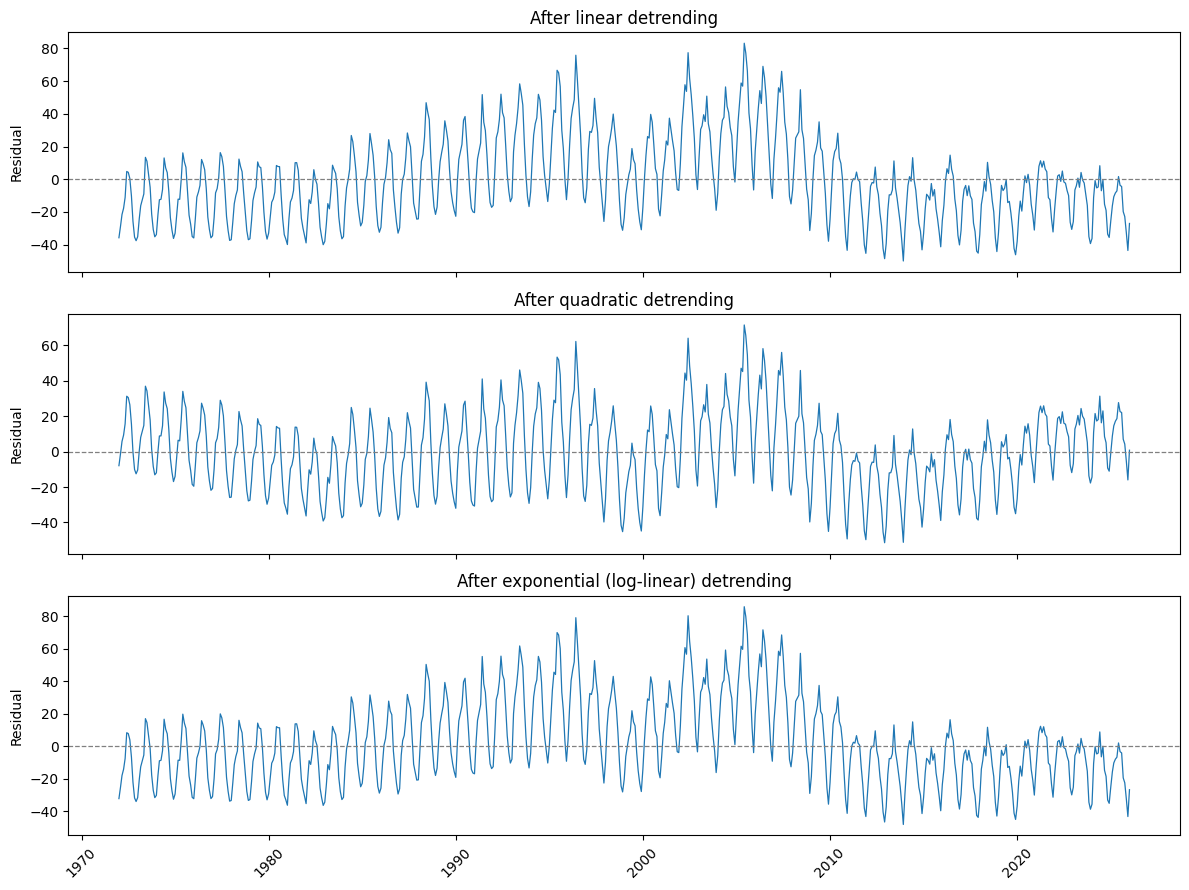

Augmented Dickey–Fuller (H0: unit root / non-stationary)

Linear detrended: ADF = -1.5417, p-value = 0.512810 (lags=20, n=628)
    critical values: 1%=-3.441, 5%=-2.866, 10%=-2.569

Quadratic detrended: ADF = -2.3626, p-value = 0.152560 (lags=20, n=628)
    critical values: 1%=-3.441, 5%=-2.866, 10%=-2.569

Exponential detrended: ADF = -1.4616, p-value = 0.552437 (lags=20, n=628)
    critical values: 1%=-3.441, 5%=-2.866, 10%=-2.569



In [6]:
# Task 2(ii): detrend; plot residuals; compare; ADF stationarity tests.
# Run the Task 2(i) cell first (defines y, timing, trend_lin, trend_quad, trend_exp).
from statsmodels.tsa.stattools import adfuller

res_lin = y - trend_lin
res_quad = y - trend_quad
res_exp = y - trend_exp

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
labels = [
    'After linear detrending',
    'After quadratic detrending',
    'After exponential (log-linear) detrending',
]
for ax, resid, lab in zip(axes, [res_lin, res_quad, res_exp], labels):
    ax.plot(timing, resid, linewidth=0.9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.9)
    ax.set_ylabel('Residual')
    ax.set_title(lab)
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


def report_adf(name, series):
    x = np.asarray(series, dtype=float)
    x = x[np.isfinite(x)]
    adf_stat, pval, usedlag, nobs, crit, _ = adfuller(x, autolag='AIC')
    print(f'{name}: ADF = {adf_stat:.4f}, p-value = {pval:.6f} (lags={usedlag}, n={nobs})')
    print(
        f'    critical values: 1%={crit["1%"]:.3f}, 5%={crit["5%"]:.3f}, 10%={crit["10%"]:.3f}'
    )


print('Augmented Dickey–Fuller (H0: unit root / non-stationary)\n')
for name, resid in [
    ('Linear detrended', res_lin),
    ('Quadratic detrended', res_quad),
    ('Exponential detrended', res_exp),
]:
    report_adf(name, resid)
    print()

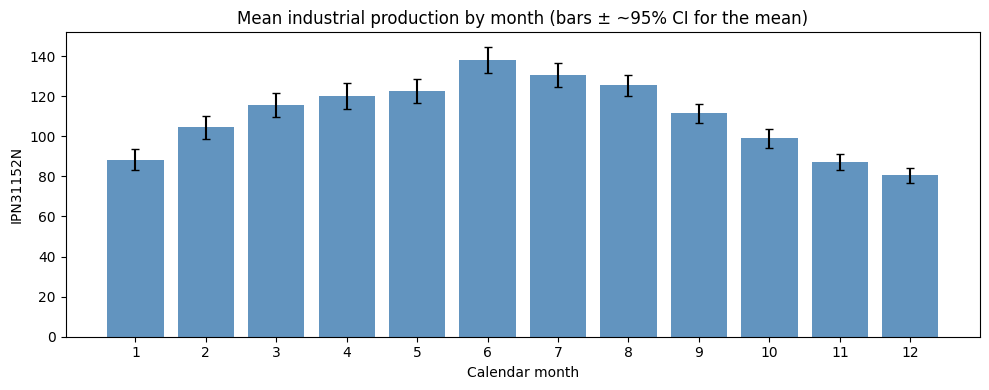

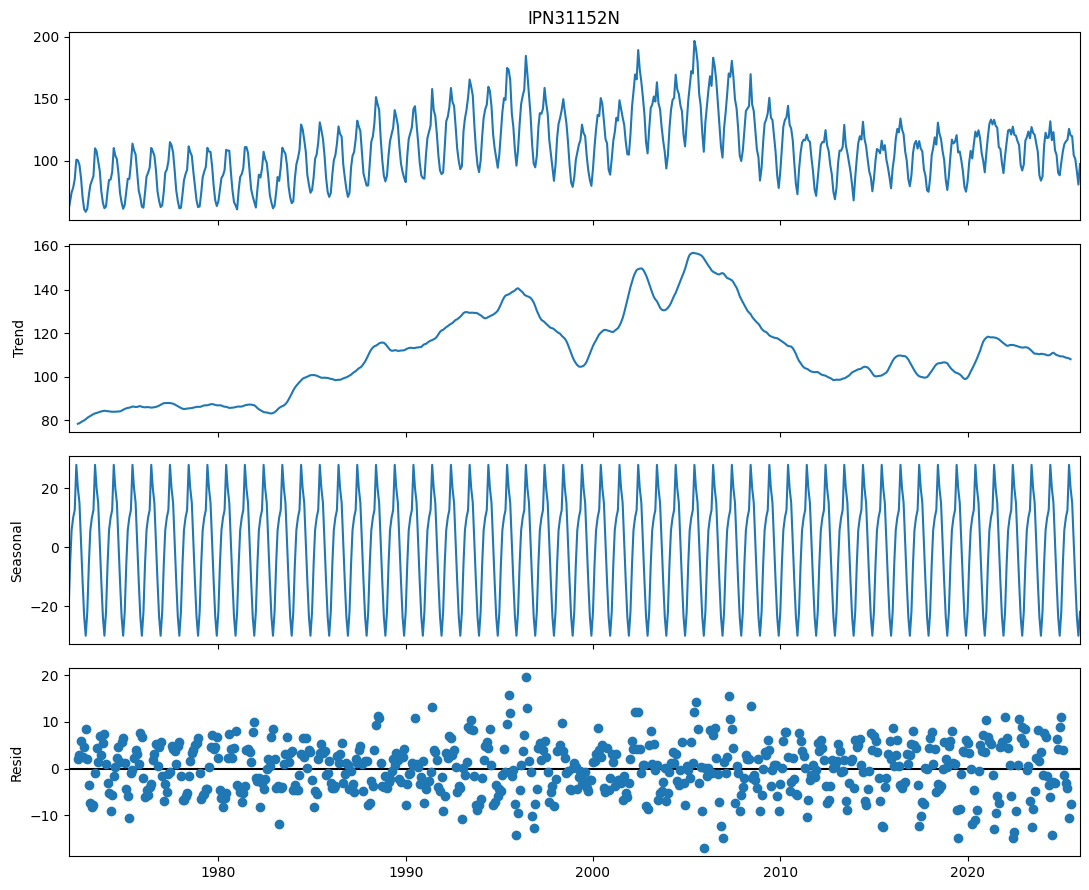

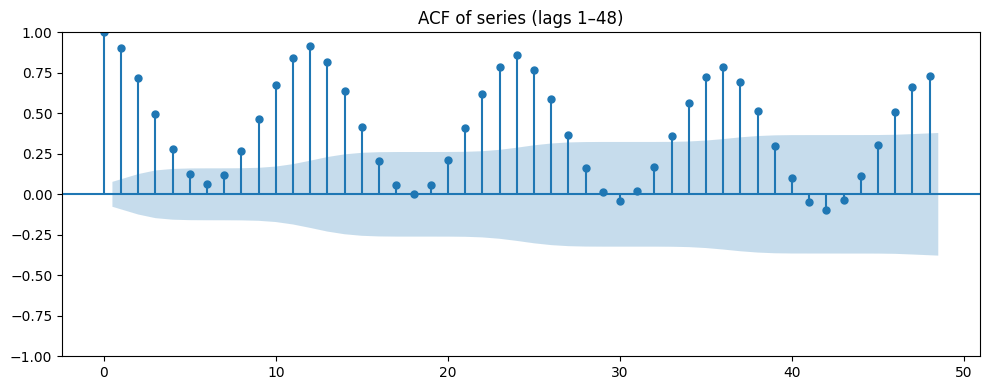

OLS: IPN31152N ~ C(month)  (month fixed effects; one month is reference)
Joint test H0: all month effects jointly zero — F = 44.6171, p-value = 8.4700e-72
Reject H0 at 5%: strong evidence of seasonality (month dummies matter).

Kruskal–Wallis (same distribution of levels across months?): statistic = 297.0036, p-value = 3.7471e-57
Reject H0 at 5%: monthly groups differ (consistent with seasonality).



In [7]:
# Task 2(iii): seasonality — graphs and formal tests

import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import kruskal

df_s = df.copy()
df_s['month'] = df_s['observation_date'].dt.month

# 1) Average level by calendar month (shows repeating seasonal shape)
month_stats = df_s.groupby('month')['IPN31152N'].agg(['mean', 'std', 'count'])
month_stats['se'] = month_stats['std'] / np.sqrt(month_stats['count'])

fig, ax = plt.subplots(figsize=(10, 4))
months = month_stats.index
ax.bar(months, month_stats['mean'], yerr=1.96 * month_stats['se'], capsize=3, color='steelblue', alpha=0.85)
ax.set_xticks(months)
ax.set_xlabel('Calendar month')
ax.set_ylabel('IPN31152N')
ax.set_title('Mean industrial production by month (bars ± ~95% CI for the mean)')
plt.tight_layout()
plt.show()

# 2) Classical additive decomposition (trend + seasonal + residual, period 12)
y_idx = df_s.set_index('observation_date')['IPN31152N'].sort_index()
decomp = seasonal_decompose(y_idx, model='additive', period=12)
fig_d = decomp.plot()
fig_d.set_size_inches(11, 9)
plt.tight_layout()
plt.show()

# 3) ACF — spikes at lags 12, 24, … indicate seasonal dependence
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(y_idx, lags=48, ax=ax, title='ACF of series (lags 1–48)')
plt.tight_layout()
plt.show()

# Formal tests for seasonal pattern (different levels across months)
fit_m = smf.ols('IPN31152N ~ C(month)', data=df_s).fit()
print('OLS: IPN31152N ~ C(month)  (month fixed effects; one month is reference)')
print(
    f"Joint test H0: all month effects jointly zero — F = {fit_m.fvalue:.4f}, "
    f"p-value = {fit_m.f_pvalue:.4e}"
)
if fit_m.f_pvalue < 0.05:
    print('Reject H0 at 5%: strong evidence of seasonality (month dummies matter).\n')
else:
    print('Do not reject H0 at 5%.\n')

groups = [df_s.loc[df_s['month'] == m, 'IPN31152N'].values for m in range(1, 13)]
kw_stat, kw_p = kruskal(*groups)
print(
    f'Kruskal–Wallis (same distribution of levels across months?): '
    f'statistic = {kw_stat:.4f}, p-value = {kw_p:.4e}'
)
if kw_p < 0.05:
    print('Reject H0 at 5%: monthly groups differ (consistent with seasonality).\n')
else:
    print('Do not reject H0 at 5%.\n')

In [8]:
# Task 2(iv): regression with deterministic trend + seasonal dummies; save residuals for Task 3

import numpy as np
import statsmodels.formula.api as smf

df_reg = df.copy()
df_reg['t'] = np.arange(len(df_reg), dtype=float)
df_reg['month'] = df_reg['observation_date'].dt.month

fit_ts = smf.ols('IPN31152N ~ t + C(month)', data=df_reg).fit()
print(fit_ts.summary())

residuals_task2iv = pd.Series(
    fit_ts.resid.to_numpy(),
    index=df_reg['observation_date'],
    name='residuals_trend_season',
)

print(
    f"Coefficient on t (linear trend): {fit_ts.params['t']:.6f} "
    f"(expected change in IPN31152N per month, holding month fixed); "
    f"p-value = {fit_ts.pvalues['t']:.4e}."
)
month_names = [c for c in fit_ts.params.index if c.startswith('C(month)')]
R = np.zeros((len(month_names), len(fit_ts.params)))
for i, name in enumerate(month_names):
    R[i, fit_ts.params.index.get_loc(name)] = 1
ft_season = fit_ts.f_test(R)
print(
    f"\nF-test H0: all month dummy coefficients = 0 (trend unrestricted): "
    f"F = {float(np.squeeze(ft_season.fvalue)):.4f}, "
    f"p = {float(np.squeeze(ft_season.pvalue)):.4e}"
)



                            OLS Regression Results                            
Dep. Variable:              IPN31152N   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     60.56
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           7.06e-97
Time:                        12:29:26   Log-Likelihood:                -2807.6
No. Observations:                 649   AIC:                             5641.
Df Residuals:                     636   BIC:                             5699.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         73.8347      2.791     26.

### Task 3

3.

(i) (0.25) Check the stationarity of the original series using ADF tests. Plot the series and comment on the observed non-stationarity: is it due to trend, seasonality, or both?

(ii) (0.25) Take the residuals from the regression model in Task 2(iv), where both trend and seasonality were removed. Plot the residuals and re-check stationarity. If the residuals are stationary proceed to 3(iii) with d=0. If the residuals are still non-stationary this suggests the trend or seasonality were not adequately captured by the regression; return to the original series and proceed as follows:

• Apply seasonal differencing: ỹt = yt − yt−12 ; plot and check stationarity;

• If still non-stationary, apply regular differencing: ∆ỹt = ỹt − ỹt−1 ; plot and re-check.

(iii) (0.25) Plot ACF and PACF of the stationary series. Based on the plots, suggest ARIMA(p, d, q) model parameters. Note which differencing steps were applied – this determines d.

(iv) (0.25) Estimate at least three ARIMA models: the one you selected; a simpler one; a more complex one. Compare the models by AIC.

(v) (0.25) For the selected final model analyze the residuals. Plot ACF/PACF. Check the residuals for autocorrelation; stationarity. Perform LjungBox test. Draw a conclusion regarding the model’s adequacy.

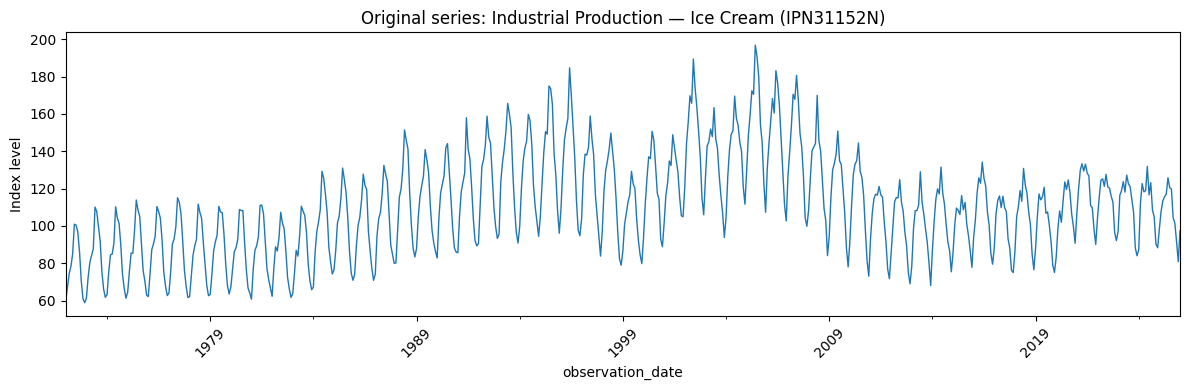

Original level series: ADF statistic = -1.8139, p-value = 0.373596, lags = 20, n = 628
  Critical values: 1% = -3.441, 5% = -2.866, 10% = -2.569


In [9]:
# Task 3(i): stationarity of the original series (ADF) + time plot

y_orig = df.set_index('observation_date')['IPN31152N'].sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
y_orig.plot(ax=ax, linewidth=1)
ax.set_title('Original series: Industrial Production — Ice Cream (IPN31152N)')
ax.set_ylabel('Index level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


def adf_report(name, x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    adf, p, lag, nobs, crit, _ = adfuller(x, autolag='AIC')
    print(f'{name}: ADF statistic = {adf:.4f}, p-value = {p:.6f}, lags = {lag}, n = {nobs}')
    print(
        f'  Critical values: 1% = {crit["1%"]:.3f}, 5% = {crit["5%"]:.3f}, 10% = {crit["10%"]:.3f}'
    )
    return p


p_level = adf_report('Original level series', y_orig)

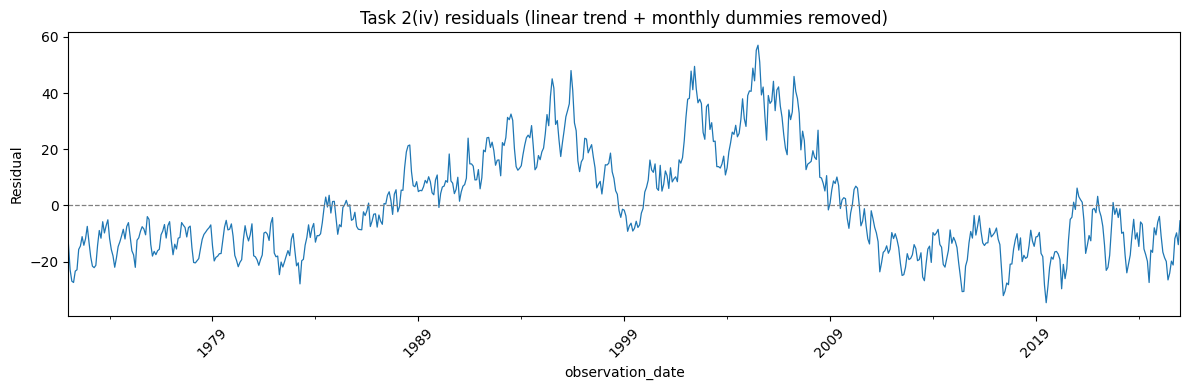

ADF on regression residuals: p-value = 0.546968

Residuals not stationary at 5% → follow the brief: seasonal differencing on the **original** series, then regular differencing if still needed.


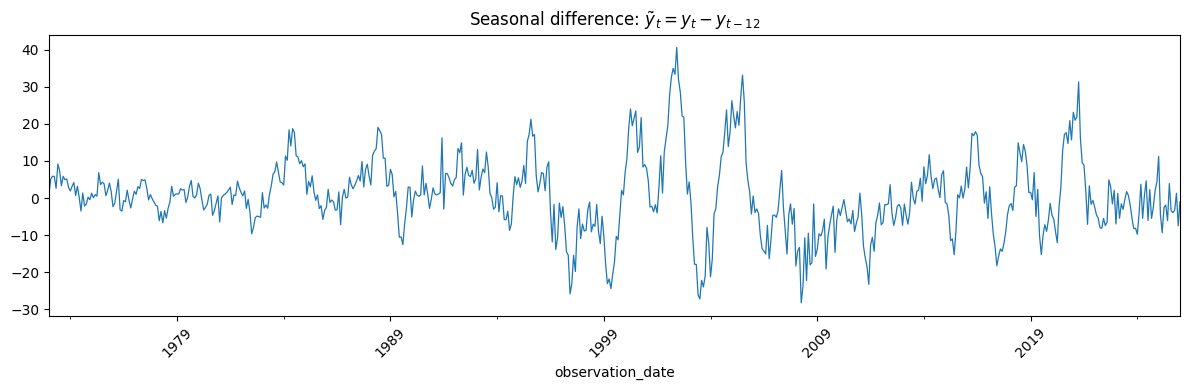

ADF after seasonal difference: p-value = 0.001428
Seasonally differenced series stationary at 5% → use it in 3(iii) with ARIMA(p,0,q).


In [10]:
# Task 3(ii): regression residuals from 2(iv); re-check stationarity; differencing if needed
# Requires: df, residuals_task2iv (Task 2(iv)), and ideally y_orig from 3(i)

y_orig = df.set_index('observation_date')['IPN31152N'].sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
residuals_task2iv.plot(ax=ax, linewidth=0.9)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.9)
ax.set_title('Task 2(iv) residuals (linear trend + monthly dummies removed)')
ax.set_ylabel('Residual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

r = residuals_task2iv.dropna().to_numpy(dtype=float)
adf_r, p_resid, *_rest = adfuller(r, autolag='AIC')
print(f'ADF on regression residuals: p-value = {p_resid:.6f}')

# These flags describe what was applied before the ARIMA stage (for 3(iii)–3(iv))
used_regression_residuals = False
applied_seasonal_diff = False
applied_regular_diff_after_seasonal = False

if p_resid < 0.05:
    used_regression_residuals = True
    series_stationary = residuals_task2iv.dropna().astype(float)
    print('\nResiduals are stationary at 5% → use this series in 3(iii) with an ARIMA(p,0,q) (d=0 here).')
else:
    print(
        '\nResiduals not stationary at 5% → follow the brief: seasonal differencing on the **original** series, '
        'then regular differencing if still needed.'
    )
    y_tilde = y_orig - y_orig.shift(12)
    y_tilde.name = 'Seasonal diff'

    fig, ax = plt.subplots(figsize=(12, 4))
    y_tilde.dropna().plot(ax=ax, linewidth=0.9)
    ax.set_title(r'Seasonal difference: $\tilde y_t = y_t - y_{t-12}$')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    applied_seasonal_diff = True
    p_seas = adfuller(y_tilde.dropna(), autolag='AIC')[1]
    print(f'ADF after seasonal difference: p-value = {p_seas:.6f}')

    if p_seas < 0.05:
        series_stationary = y_tilde.dropna().astype(float)
        print('Seasonally differenced series stationary at 5% → use it in 3(iii) with ARIMA(p,0,q).')
    else:
        dy = y_tilde - y_tilde.shift(1)
        dy.name = 'Seasonal + first difference'

        fig, ax = plt.subplots(figsize=(12, 4))
        dy.dropna().plot(ax=ax, linewidth=0.9)
        ax.set_title(r'$\Delta\tilde y_t = \tilde y_t - \tilde y_{t-1}$')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        applied_regular_diff_after_seasonal = True
        p_dy = adfuller(dy.dropna(), autolag='AIC')[1]
        print(f'ADF after seasonal + regular difference: p-value = {p_dy:.6f}')
        series_stationary = dy.dropna().astype(float)


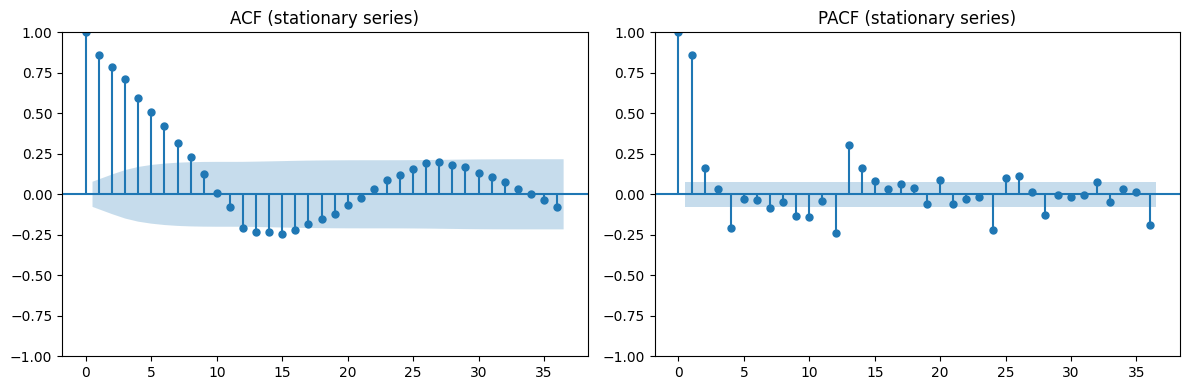

In [11]:
# Task 3(iii): ACF & PACF of the stationary series; suggest ARIMA(p,d,q)
# Requires: series_stationary from 3(ii). Fitted ARIMA below uses d=0 on this series because
# differencing / filtering is already reflected in how series_stationary was built.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

z = series_stationary.astype(float).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(z, lags=36, ax=axes[0], title='ACF (stationary series)')
plot_pacf(z, lags=36, ax=axes[1], method='ywm', title='PACF (stationary series)')
plt.tight_layout()
plt.show()

# Adjust these after inspecting your plots (cut-off after lag p for AR, after lag q for MA)
ORDER_SUGGESTED = (2, 0, 1)

In [12]:
# Task 3(iv): estimate ≥3 ARIMA models; compare AIC
# Requires: series_stationary, ORDER_SUGGESTED from 3(iii)

from statsmodels.tsa.arima.model import ARIMA

z = series_stationary.astype(float).dropna()
p0, _, q0 = ORDER_SUGGESTED

simpler = (max(0, p0 - 1), 0, max(0, q0 - 1))
if simpler == (0, 0, 0):
    simpler = (1, 0, 0)
if simpler == ORDER_SUGGESTED:
    simpler = (0, 0, 1)

more = (p0 + 1, 0, q0 + 1)
if more == ORDER_SUGGESTED:
    more = (p0 + 2, 0, q0 + 1)

models_spec = [
    ('simpler', simpler),
    ('selected (from ACF/PACF)', ORDER_SUGGESTED),
    ('more complex', more),
]

arima_results = {}
for label, order in models_spec:
    fit = ARIMA(z, order=order).fit()
    arima_results[label] = fit
    print(f'{label:28s} ARIMA{order}  AIC = {fit.aic:,.2f}  BIC = {fit.bic:,.2f}')

best_label = min(arima_results, key=lambda k: arima_results[k].aic)
arima_final = arima_results[best_label]
print(f'\nBest by AIC: {best_label} → ARIMA{arima_final.model.order}')

simpler                      ARIMA(1, 0, 0)  AIC = 3,879.42  BIC = 3,892.79


/Users/yaremakertytsky/Documents/Studying/semester4/econometrics/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/yaremakertytsky/Documents/Studying/semester4/econometrics/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/yaremakertytsky/Documents/Studying/semester4/econometrics/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/yaremakertytsky/Documents/Studying/semester4/econometrics/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequen

selected (from ACF/PACF)     ARIMA(2, 0, 1)  AIC = 3,866.45  BIC = 3,888.73
more complex                 ARIMA(3, 0, 2)  AIC = 3,829.54  BIC = 3,860.73

Best by AIC: more complex → ARIMA(3, 0, 2)


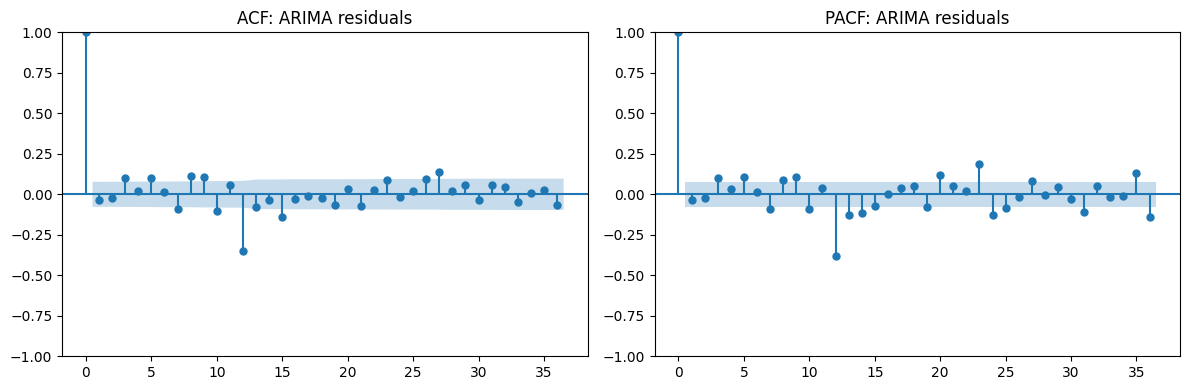

ADF on ARIMA residuals: p-value = 0.000000

Ljung–Box test on ARIMA residuals (H0: no autocorrelation up to lag L):
       lb_stat     lb_pvalue
12  123.387481  1.508139e-23
24  154.781162  2.610410e-23


In [13]:
# Task 3(v): residual diagnostics for the chosen ARIMA; Ljung–Box; brief conclusion
# Requires: arima_final from 3(iv)

import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = arima_final.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, lags=36, ax=axes[0], title='ACF: ARIMA residuals')
plot_pacf(resid, lags=36, ax=axes[1], method='ywm', title='PACF: ARIMA residuals')
plt.tight_layout()
plt.show()

_, p_adf_res, *_ = adfuller(resid, autolag='AIC')
print(f'ADF on ARIMA residuals: p-value = {p_adf_res:.6f}')

p_ar, d_ar, q_ar = arima_final.model.order
lb = acorr_ljungbox(
    resid,
    lags=[12, 24],
    model_df=p_ar + q_ar,
    return_df=True,
)
print('\nLjung–Box test on ARIMA residuals (H0: no autocorrelation up to lag L):')
print(lb.to_string())

### Task 4

4. (0.25pt.) Build a forecast for the next 12 periods. Plot historical data and the forecast; confidence intervals. Briefly comment on the results.

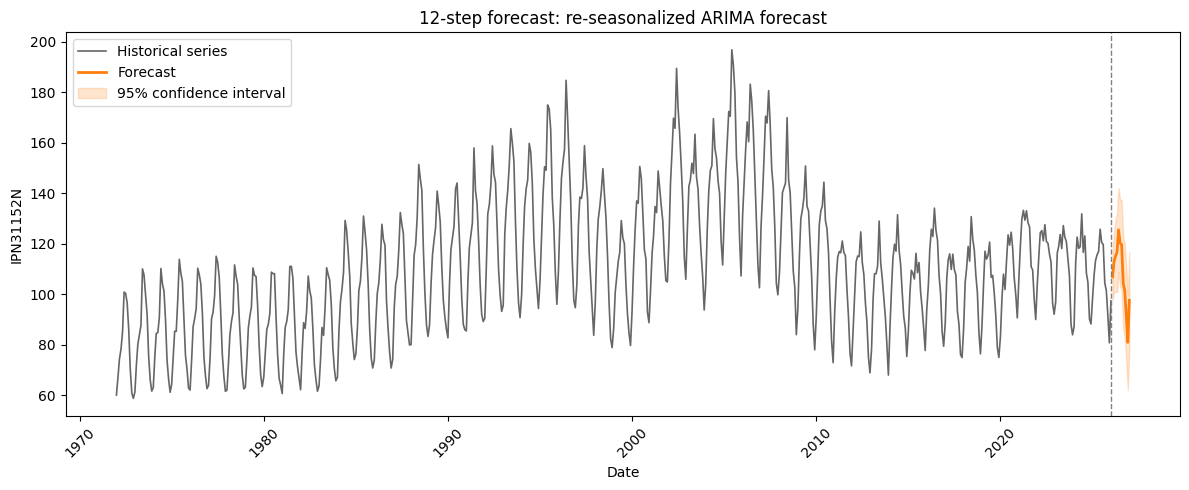

Forecast for the next 12 periods:
            forecast  lower_ci  upper_ci
2026-02-01   106.913    97.457   116.369
2026-03-01   112.632   100.754   124.511
2026-04-01   115.167   101.152   129.182
2026-05-01   116.606   100.822   132.391
2026-06-01   125.532   108.894   142.170
2026-07-01   120.324   103.178   137.471
2026-08-01   119.704   101.939   137.469
2026-09-01   104.477    86.200   122.755
2026-10-01   101.576    83.076   120.075
2026-11-01    91.664    73.003   110.326
2026-12-01    81.019    62.128    99.909
2027-01-01    97.640    78.586   116.693


In [16]:
# Task 4: 12-step forecast with confidence intervals
# Requires: arima_final from Task 3(iv) and the preprocessing flags from Task 3(ii).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

horizon = 12
y_orig = df.set_index('observation_date')['IPN31152N'].sort_index()
y_index = pd.DatetimeIndex(y_orig.index)
freq = pd.infer_freq(y_index) or 'MS'
future_index = pd.date_range(start=y_index[-1], periods=horizon + 1, freq=freq)[1:]

arima_forecast = arima_final.get_forecast(steps=horizon)
arima_mean = arima_forecast.predicted_mean.to_numpy()
arima_ci = arima_forecast.conf_int(alpha=0.05).to_numpy()

if 'used_regression_residuals' in globals() and used_regression_residuals:
    future_t = np.arange(len(df_reg), len(df_reg) + horizon, dtype=float)
    future_months = future_index.month
    future_df = pd.DataFrame({'t': future_t, 'month': future_months}, index=future_index)

    trend_forecast = fit_ts.predict(future_df)
    forecast_mean = trend_forecast.to_numpy() + arima_mean
    forecast_lower = trend_forecast.to_numpy() + arima_ci[:, 0]
    forecast_upper = trend_forecast.to_numpy() + arima_ci[:, 1]
    forecast_title = '12-step forecast: trend + seasonality + ARIMA residuals'
elif 'applied_seasonal_diff' in globals() and applied_seasonal_diff:
    seasonal_base = y_orig.iloc[-12:].to_numpy()

    if 'applied_regular_diff_after_seasonal' in globals() and applied_regular_diff_after_seasonal:
        y_tilde = (y_orig - y_orig.shift(12)).dropna()
        y_tilde_last = y_tilde.iloc[-1]

        cum_mean = np.cumsum(arima_mean)
        cum_lower = np.cumsum(arima_ci[:, 0])
        cum_upper = np.cumsum(arima_ci[:, 1])

        seasonal_forecast = y_tilde_last + cum_mean
        seasonal_lower = y_tilde_last + cum_lower
        seasonal_upper = y_tilde_last + cum_upper
    else:
        seasonal_forecast = arima_mean
        seasonal_lower = arima_ci[:, 0]
        seasonal_upper = arima_ci[:, 1]

    forecast_mean = seasonal_base + seasonal_forecast
    forecast_lower = seasonal_base + seasonal_lower
    forecast_upper = seasonal_base + seasonal_upper
    forecast_title = '12-step forecast: re-seasonalized ARIMA forecast'
else:
    forecast_mean = arima_mean
    forecast_lower = arima_ci[:, 0]
    forecast_upper = arima_ci[:, 1]
    forecast_title = '12-step ARIMA forecast'

forecast_df = pd.DataFrame(
    {
        'forecast': forecast_mean,
        'lower_ci': forecast_lower,
        'upper_ci': forecast_upper,
    },
    index=future_index,
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_index.to_pydatetime(), y_orig.to_numpy(), color='0.4', linewidth=1.2, label='Historical series')
ax.plot(
    forecast_df.index.to_pydatetime(),
    forecast_df['forecast'].to_numpy(),
    color='C1',
    linewidth=2,
    label='Forecast',
)
ax.fill_between(
    forecast_df.index.to_pydatetime(),
    forecast_df['lower_ci'].to_numpy(),
    forecast_df['upper_ci'].to_numpy(),
    color='C1',
    alpha=0.2,
    label='95% confidence interval',
)
ax.axvline(y_index[-1].to_pydatetime(), color='gray', linestyle='--', linewidth=1)
ax.set_title(forecast_title)
ax.set_xlabel('Date')
ax.set_ylabel('IPN31152N')
ax.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Forecast for the next 12 periods:')
print(forecast_df.round(3).to_string())

### Task 5

5. (0.25 pt) Which approach (classical or ARIMA) yielded more informative results for this time series? Why? Is it possible to combine these approaches in a single model? In which cases is it appropriate to use decomposition only; ARIMA only; a combined approach.